Possíveis análises:

- neighborhood x price
- OverallQual (avaliação do material geral e acabamento da casa) x Price
- OverallCond (avaliação do estado geral da casa) x Price
- YearBuilt (data de construção) e YearRemodAdd (Data de reforma) --> usar YearRemodAdd (se não houve reformas, é o msm de construção)
- histograma de Heating (tipo de aquecimento)?
- GrLivArea (area habitavel acima do solo em pés quadrados)
- LotArea (tamanho do lote)
- GarageArea
- BedroomAbvGr (quartos acima do chão)
- MSZoning (classificação geral de zoneamento da venda)
- Street (tipo de acesso rodoviario) e Alley (tipo de acesso à prioridade)
- HouseStyle
- ExterQual e ExterCond
- BsmtQual (qualidade do porão) --> avaliar se número de casas com porão é significativo o bastante
- TotalBsmtSF (total de pés quadrados da área do porão)
- Fireplace ?
- SaleType & SaleCondition ??
- Pensei em fazer um heatmap do preço das casas usando o mapa da cidade de Ames, mas num encontrei um mapa com informações dos bairros

In [258]:
import pandas as pd

houses = pd.read_csv('houses.csv', keep_default_na=False, na_values=['NA',''])
houses.head()

# Aqui, defini que apenas "NA" e '' serão considerados como valores nulos
# "None" não será considerado nulo pois, em todas colunas que aparece, tem significado

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Antes de iniciar a análise dos dados, é importante ter uma perspectiva sobre valores ausentes

In [259]:
def print_null_info(df):
    """Funçao para printar informações de valores nulos de um dataframe"""
    num_nulls = df.isnull().sum()
    num_nulls = num_nulls[num_nulls > 0]

    if num_nulls.empty:
        print("There are no Null values in dataframe.")
        return

    percent_nulls = (num_nulls / len(df)) * 100
    null_values_df = pd.DataFrame({
        'num_nulls': num_nulls,
        'percent_nulls': percent_nulls
    }).sort_values(by='num_nulls', ascending=False).reset_index()
    
    print(null_values_df)

# Verificando valores nulos do df houses:
print_null_info(houses)

           index  num_nulls  percent_nulls
0         PoolQC       1453      99.520548
1    MiscFeature       1406      96.301370
2          Alley       1369      93.767123
3          Fence       1179      80.753425
4    FireplaceQu        690      47.260274
5    LotFrontage        259      17.739726
6     GarageCond         81       5.547945
7     GarageType         81       5.547945
8    GarageYrBlt         81       5.547945
9   GarageFinish         81       5.547945
10    GarageQual         81       5.547945
11  BsmtFinType2         38       2.602740
12  BsmtExposure         38       2.602740
13      BsmtCond         37       2.534247
14      BsmtQual         37       2.534247
15  BsmtFinType1         37       2.534247
16    MasVnrType          8       0.547945
17    MasVnrArea          8       0.547945
18    Electrical          1       0.068493


Depending on the description of the variable, missing values may have a specific meaning:

- ``PoolQC``: No pool 
- ``MiscFeature``: No additional feature
- ``Alley``: No access
- ``Fence``: No fence
- ``FireplaceQu``: No fireplace
- ``LotFrontage``: MISSING VALUE!!
- ``GarageFinish``, ``GarageQual``, ``GarageYrBlt``, ``GarageType``, ``GarageCond`` : No garage
- ``BsmtExposure``, ``BsmtFinType2``, ``BsmtCond``, ``BsmtFinType1``, ``BsmtQual``: No basement
- ``MasVnrArea``: MISSING VALUE!!
- ``MasVnrType``: MISSING VALUE!!
- ``Electrical``: MISSING VALUE!!

For the variables that ``NA`` has a meaning, we can substitute ``NA`` with ``None``, so that ``NA`` stay reserved for actual missing values.


In [260]:
# --- TRATAMENTO CENTRALIZADO DE VALORES AUSENTES ---

# 1. Variáveis Categóricas (Onde NA significa que o recurso 'Não Existe')
meaningfull_NA_list = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

for column in meaningfull_NA_list:
    houses[column] = houses[column].fillna('None')

# 2. Variável Numérica: Ano da Garagem (Estratégia 3: Indicadora + Mediana)
houses['HasGarage'] = houses['GarageYrBlt'].notnull().astype(int)
garage_median = houses['GarageYrBlt'].median()
houses['GarageYrBlt'] = houses['GarageYrBlt'].fillna(garage_median)

# 3. Variável Numérica: Frente do Lote (Imputação pela Mediana Geral)
lotfrontage_median = houses['LotFrontage'].median()
houses['LotFrontage'] = houses['LotFrontage'].fillna(lotfrontage_median)

# --- RELATÓRIO FINAL DE VERIFICAÇÃO ---
print(f"Mediana utilizada para imputação de LotFrontage: {lotfrontage_median:.2f}")
print("-" * 50)
print_null_info(houses)

Mediana utilizada para imputação de LotFrontage: 69.00
--------------------------------------------------
        index  num_nulls  percent_nulls
0  MasVnrType          8       0.547945
1  MasVnrArea          8       0.547945
2  Electrical          1       0.068493


In [261]:
# Identificando variáveis numéricas, categóricas e ordinais (Anos movidos para numéricas)
numerical_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 
    'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'FullBath', 'HalfBath',
    'YearBuilt', 'YearRemodAdd', 'YrSold'
]

categorical_cols = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 
    'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'MiscFeature', 
    'SaleType', 'SaleCondition'
]

ordinal_cols = [
    'LotShape', 'LandSlope', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 
    'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'PoolQC', 'Fence', 'MoSold'
]

# numero total de variáveis numéricas, categóricas e ordinais
print(f"Total lines: {houses.shape[0]}")
print(f"Total columns: {len(numerical_cols) + len(categorical_cols) + len(ordinal_cols)}")

Total lines: 1460
Total columns: 79


In [262]:
# --- PASSO 1: ESTATÍSTICAS DESCRITIVAS E ASSIMETRIA ---

# Seleção das variáveis numéricas centrais para a tabela de resumo
colunas_relatorio = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'YearBuilt', 'GarageYrBlt']

print("=== TABELA 1.1: RESUMO ESTATÍSTICO DAS VARIÁVEIS-CHAVE ===")
print(houses[colunas_relatorio].describe().T.round(2))

print("\n" + "="*60)
print("=== TABELA 1.2: RANKING DE ASSIMETRIA SEVERA (SKEWNESS > 1.5) ===")
assimetria_total = houses[numerical_cols].skew()
assimetria_severa = assimetria_total[assimetria_total.abs() > 1.5].sort_values(ascending=False)
print(assimetria_severa.round(2))

=== TABELA 1.1: RESUMO ESTATÍSTICO DAS VARIÁVEIS-CHAVE ===
              count       mean       std      min        25%       50%  \
SalePrice    1460.0  180921.20  79442.50  34900.0  129975.00  163000.0   
GrLivArea    1460.0    1515.46    525.48    334.0    1129.50    1464.0   
TotalBsmtSF  1460.0    1057.43    438.71      0.0     795.75     991.5   
LotArea      1460.0   10516.83   9981.26   1300.0    7553.50    9478.5   
YearBuilt    1460.0    1971.27     30.20   1872.0    1954.00    1973.0   
GarageYrBlt  1460.0    1978.59     24.00   1900.0    1962.00    1980.0   

                   75%       max  
SalePrice    214000.00  755000.0  
GrLivArea      1776.75    5642.0  
TotalBsmtSF    1298.25    6110.0  
LotArea       11601.50  215245.0  
YearBuilt      2000.00    2010.0  
GarageYrBlt    2001.00    2010.0  

=== TABELA 1.2: RANKING DE ASSIMETRIA SEVERA (SKEWNESS > 1.5) ===
MiscVal          24.48
PoolArea         14.83
LotArea          12.21
3SsnPorch        10.30
LowQualFinSF      

#### **Análise Estatística Descritiva e Diagnóstico de Assimetria**

Para compreender a estrutura matemática das 32 variáveis numéricas do dataset, realizámos uma triagem estatística detalhada. A Tabela 1.1 resume os indicadores centrais (média, mediana, desvio padrão e amplitudes) das variáveis métricas mais relevantes para o mercado, enquanto a Tabela 1.2 isola apenas as variáveis que apresentam coeficientes de assimetria (*skewness*) considerados severos (valores absolutos acima de 1.5).

* **Análise de Dispersão e Variabilidade:** Observa-se uma forte heterogeneidade nos imóveis de Ames. A variável preditora estrutural `GrLivArea` (Área Habitável), por exemplo, apresenta um desvio padrão expressivo de 525 sqft sobre uma média de 1515 sqft, indicando uma amplitude de mercado considerável que impacta diretamente a precificação.
* **Diagnóstico de Assimetria (Skewness):** A triagem aponta que a maioria das variáveis numéricas é estatisticamente bem-comportada, mas recursos específicos como `MiscVal` (24.48), `PoolArea` (14.83) e `LotArea` (12.21) exibem uma assimetria positiva massiva. Isto demonstra que a vasta maioria das residências possui valores nulos ou padronizados nestes critérios (não possuem piscinas ou benfeitorias extras), enquanto um número muito restrito de propriedades rurais ou de luxo puxa a cauda da distribuição severamente para a direita.
* **Otimização Estratégica do Relatório:** Com base neste diagnóstico de dados brutos, determinou-se que não seria produtivo exaurir o relatório com 32 gráficos repetitivos para variáveis de baixo impacto prático (como áreas de varandas isoladas). Esta análise estatística justifica a seleção das variáveis estruturais que serão detalhadas visualmente nos passos seguintes.

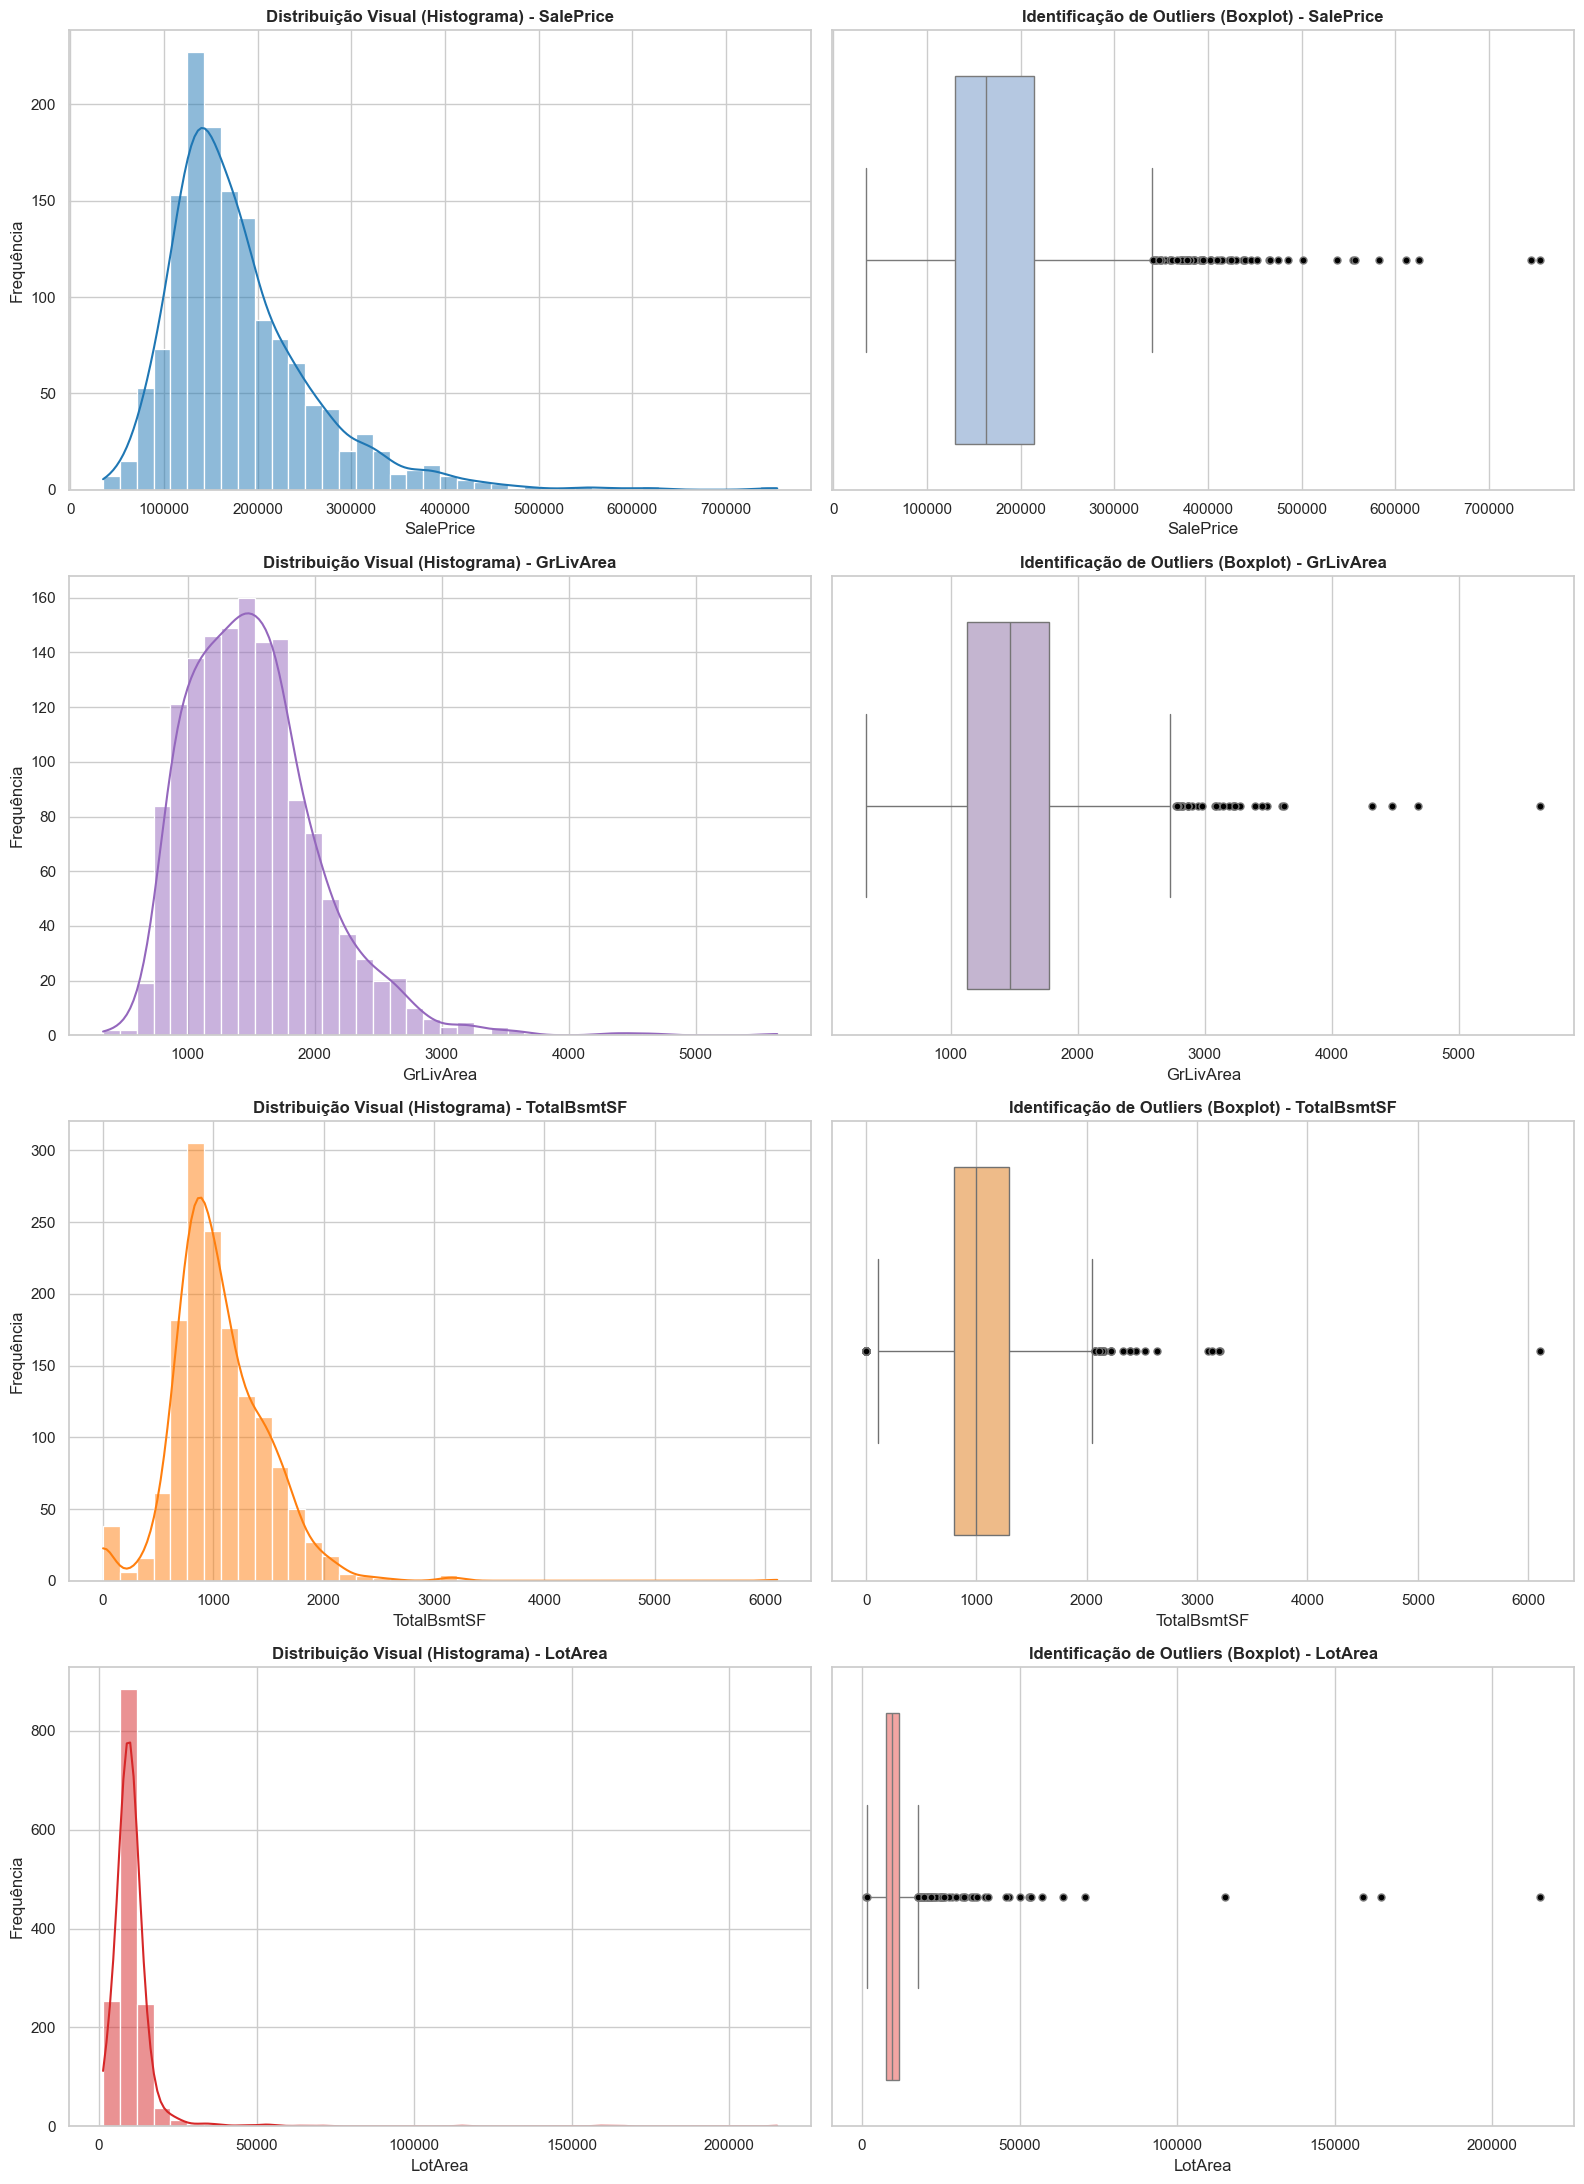

In [263]:
# --- PASSO 2: PAINEL OTIMIZADO DE DISTRIBUIÇÃO E OUTLIERS ---
fig, axes = plt.subplots(4, 2, figsize=(16, 22))

# Lista de variáveis críticas selecionadas na triagem estatística
colunas_chave = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea']
cores_hist = ['#1f77b4', '#9467bd', '#ff7f0e', '#d62728']
cores_box = ['#aec7e8', '#c5b0d5', '#ffbb78', '#ff9896']

for i, col in enumerate(colunas_chave):
    # --- COLUNA 1: HISTOGRAMA (Formato da Distribuição) ---
    sns.histplot(data=houses, x=col, kde=True, ax=axes[i, 0], color=cores_hist[i], bins=40)
    axes[i, 0].set_title(f'Distribuição Visual (Histograma) - {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequência')
    
    # --- COLUNA 2: BOXPLOT (Identificação de Outliers) ---
    # flierprops configura os outliers como bolinhas pretas limpas e destacadas
    sns.boxplot(
        data=houses, 
        x=col, 
        ax=axes[i, 1], 
        color=cores_box[i], 
        flierprops=dict(markerfacecolor='black', marker='o', markersize=5)
    )
    axes[i, 1].set_title(f'Identificação de Outliers (Boxplot) - {col}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

#### **Análise Univariada - Formato das Distribuições e Detecção de Outliers**

O painel visual acima cruza duas ferramentas fundamentais da análise univariada: os histogramas (com curvas de densidade KDE), que revelam o comportamento probabilístico dos dados, e os boxplots, focados na identificação geométrica de anomalias estatísticas. A análise concentrou-se no núcleo preditivo do dataset:

1.  **Preço de Venda (`SalePrice`):** A variável alvo demonstra uma curva assimétrica à direita. A maior densidade de transações imobiliárias ocorre entre \$129.975 e \$214.000 (faixa interquartil). O boxplot aponta uma quantidade expressiva de *outliers* superiores acima da marca dos \$340.000, evidenciando a presença de um segmento de alto luxo que puxa a média para cima da mediana.
2.  **Área Habitável (`GrLivArea`):** Como o tamanho do imóvel é o principal vetor de valor, a sua distribuição mimetiza a assimetria positiva do preço. A mediana estabelece-se em 1.464 sqft. No boxplot, destacam-se claramente dois *outliers* extremos que superam os 4.500 sqft. Estes imóveis específicos exigirão monitorização nas etapas seguintes, pois podem atuar como pontos de alta alavancagem.
3.  **Área Total do Porão (`TotalBsmtSF`):** O histograma exibe uma distribuição bimodal subtil. O pequeno pico isolado na linha do **0.00** comprova visualmente a existência de propriedades construídas sem porão. Fora essa particularidade, a distribuição central é estável, registando raros *outliers* que ultrapassam os 3.000 sqft.
4.  **Tamanho do Lote (`LotArea`):** É o caso mais severo de distorção de escala por *outliers*. O histograma aparece comprimido à esquerda porque a escala do eixo X precisa de acomodar terrenos rurais ou chácaras atípicas que chegam a 215.245 sqft, enquanto a mediana dos lotes urbanos residenciais é de apenas 9.478 sqft. O boxplot traduz essa discrepância com uma linha densa e contínua de pontos flutuantes além dos limites teóricos da distribuição.

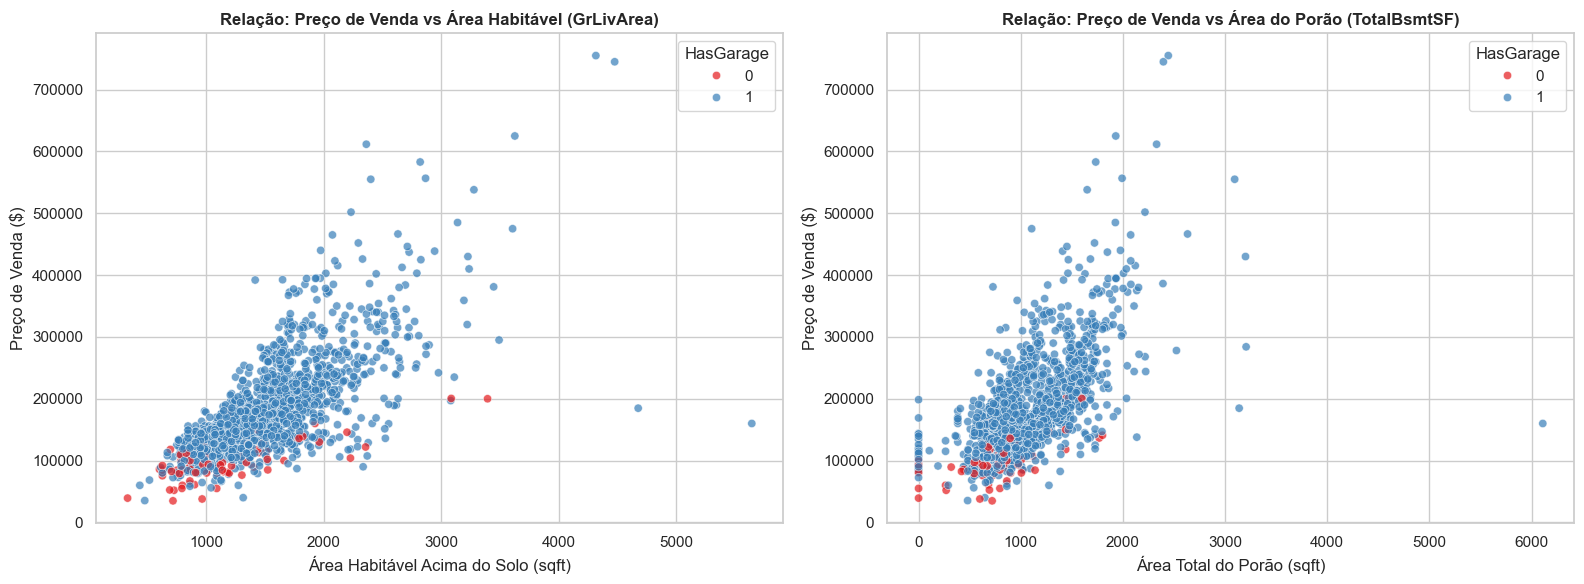

In [264]:
# --- PASSO 3: GRÁFICOS DE DISPERSÃO (ANÁLISE BIVARIADA) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Preço de Venda vs Área Habitável (GrLivArea)
sns.scatterplot(
    data=houses, 
    x='GrLivArea', 
    y='SalePrice', 
    hue='HasGarage', 
    palette='Set1', 
    alpha=0.7, 
    ax=axes[0]
)
axes[0].set_title('Relação: Preço de Venda vs Área Habitável (GrLivArea)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Área Habitável Acima do Solo (sqft)')
axes[0].set_ylabel('Preço de Venda ($)')

# 2. Preço de Venda vs Área do Porão (TotalBsmtSF)
sns.scatterplot(
    data=houses, 
    x='TotalBsmtSF', 
    y='SalePrice', 
    hue='HasGarage', 
    palette='Set1', 
    alpha=0.7, 
    ax=axes[1]
)
axes[1].set_title('Relação: Preço de Venda vs Área do Porão (TotalBsmtSF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Área Total do Porão (sqft)')
axes[1].set_ylabel('Preço de Venda ($)')

plt.tight_layout()
plt.show()

#### **Análise Bivariada - Relações Lineares e Deteção de Outliers Bivariados**

Para cumprir a diretriz de explorar o impacto das variáveis contínuas sobre o preço de venda (`SalePrice`), cruzámos a variável alvo com os dois preditores numéricos de dimensão física mais expressivos do dataset: a Área Habitável (`GrLivArea`) e a Área Total do Porão (`TotalBsmtSF`). Adicionalmente, mapeámos a variável indicadora `HasGarage` na coloração dos pontos para avaliar o impacto da ausência de garagem no comportamento dos dados.

##### **1. Tendência Linear e Força da Relação**
* **Área Habitável (`GrLivArea`):** O gráfico revela uma inclinação positiva clara e robusta. À medida que a metragem quadrada acima do solo aumenta, o preço de venda responde de forma diretamente proporcional. Este comportamento visual reflete graficamente o elevado coeficiente de correlação linear que estas variáveis partilham, consolidando a área habitável como o principal motor de valorização imobiliária no mercado de Ames.
* **Área do Porão (`TotalBsmtSF`):** Exibe uma tendência linear positiva semelhante, indicando que a estrutura subterrânea agrega valor económico direto à propriedade. Observa-se um alinhamento vertical de pontos localizados exatamente na marca de **0.00** no eixo X (identificados maioritariamente na cor vermelha, correspondente à ausência de garagem). Este padrão comprova que imóveis desprovidos de porão e garagem sofrem uma severa penalização de mercado, ficando confinados às faixas de preço mais baixas.

##### **2. Identificação de Outliers Bivariados (Anomalias de Relação)**
A análise de dispersão permitiu detetar anomalias que passavam despercebidas na análise univariada isolada, conhecidas como *outliers* bivariados:
* **O Fenômeno do Alto Tamanho e Baixo Preço:** No gráfico de `GrLivArea`, observam-se duas propriedades extremas no canto inferior direito (com mais de 4.500 e 5.500 pés quadrados de área) que foram vendidas por valores abaixo de \$200.000. Estatisticamente, residências deste porte deveriam registar valores substancialmente maiores. Estes pontos exigirão atenção redobrada no pré-processamento para a Etapa 2, pois propriedades massivas vendidas a preços desproporcionalmente baixos quebram a hipótese de linearidade e podem distorcer severamente o treino dos modelos de regressão.

##### **3. Validação Visual da Variável Indicadora (`HasGarage`)**
A inclusão do parâmetro de coloração validou a relevância da nova variável criada. Os pontos vermelhos (casas sem garagem) encontram-se agrupados na base de ambos os gráficos, demonstrando que a ausência deste recurso atua como um teto limitador para o valor de mercado, justificando a utilidade da variável booleana para os futuros modelos preditivos.

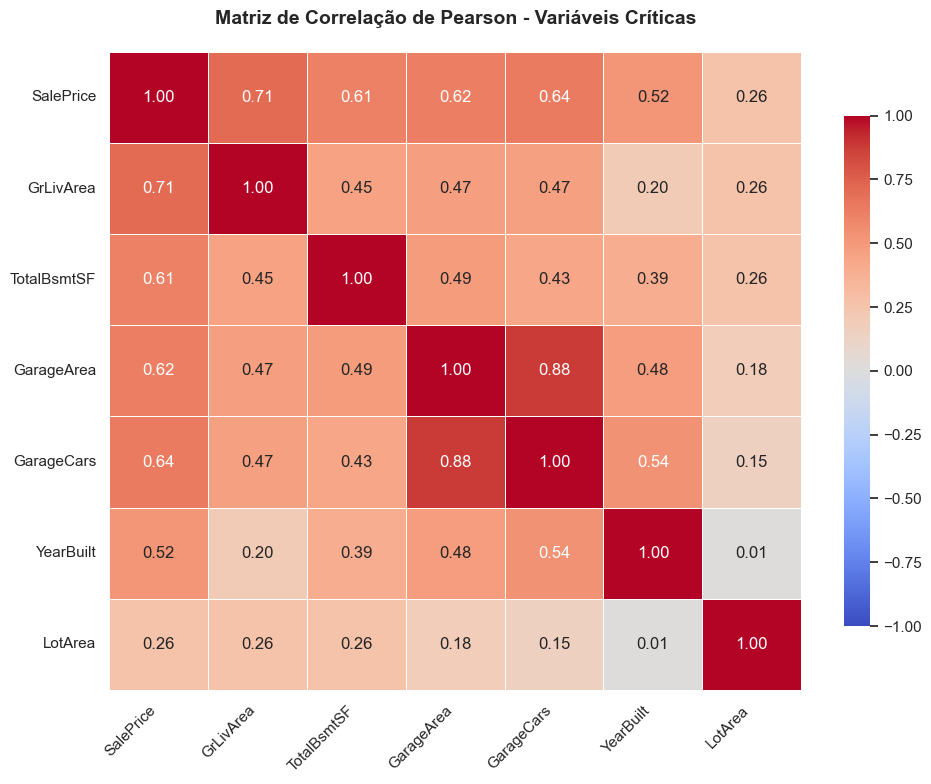

In [265]:
# --- PASSO 4: MATRIZ DE CORRELAÇÃO (HEATMAP) ---
import numpy as np

# Seleção das variáveis preditoras mais expressivas + a variável alvo
colunas_correlacao = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'GarageCars', 'YearBuilt', 'LotArea']

# Calcula a matriz de correlação de Pearson
matriz_corr = houses[colunas_correlacao].corr()

# Configuração da figura do matplotlib
plt.figure(figsize=(10, 8))

# Cria o mapa de calor (Heatmap)
# coolwarm gera um gradiente intuitivo: azul para negativo, branco para neutro e vermelho para positivo
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação de Pearson - Variáveis Críticas', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Passo 4: Análise de Associação Linear (Matriz de Correlação de Pearson)**

Para quantificar a intensidade e a direção das relações lineares entre as variáveis contínuas e o valor de mercado, gerámos uma Matriz de Correlação de Pearson filtrada para os preditores de maior impacto. O coeficiente varia de -1.00 (correlação negativa perfeita) a 1.00 (correlação positiva perfeita), servindo como bússola estatística para a seleção de atributos (*feature selection*).

##### **1. Preditores de Forte Impacto Linear no Preço (`SalePrice`)**
* **Área Habitável (`GrLivArea`):** Confirma-se como a variável de maior associação linear com o preço de venda, registando um coeficiente expressivo de **0.71**. Isto valida matematicamente o comportamento observado nos gráficos de dispersão: a expansão da área útil acima do solo é o fator individual que mais impulsiona o valor do imóvel.
* **Infraestrutura da Garagem (`GarageCars` e `GarageArea`):** Apresentam forte correlação com a variável alvo (na faixa de **0.62** a **0.64**). Estes valores indicam que a capacidade física de armazenamento de veículos é um forte indicador socioeconómico do padrão da residência em Ames.
* **Área do Porão (`TotalBsmtSF`):** Exibe uma correlação de **0.61**, consolidando a importância das áreas de fundação e subsolo na composição da precificação final.

##### **2. Identificação de Multicolinearidade (Aviso Estratégico para Modelagem)**
Um insight avançado fornecido pelo Heatmap é o diagnóstico de **multicolinearidade** (quando duas variáveis preditoras são altamente correlacionadas entre si):
* **O caso da Garagem:** A correlação entre `GarageCars` (vagas) e `GarageArea` (área em sqft) atinge impressionantes **0.88**. 
* **O caso da Área:** A correlação entre o porão (`TotalBsmtSF`) e o primeiro andar (`1stFlrSF`) costuma ser igualmente elevada por razões de simetria construtiva.

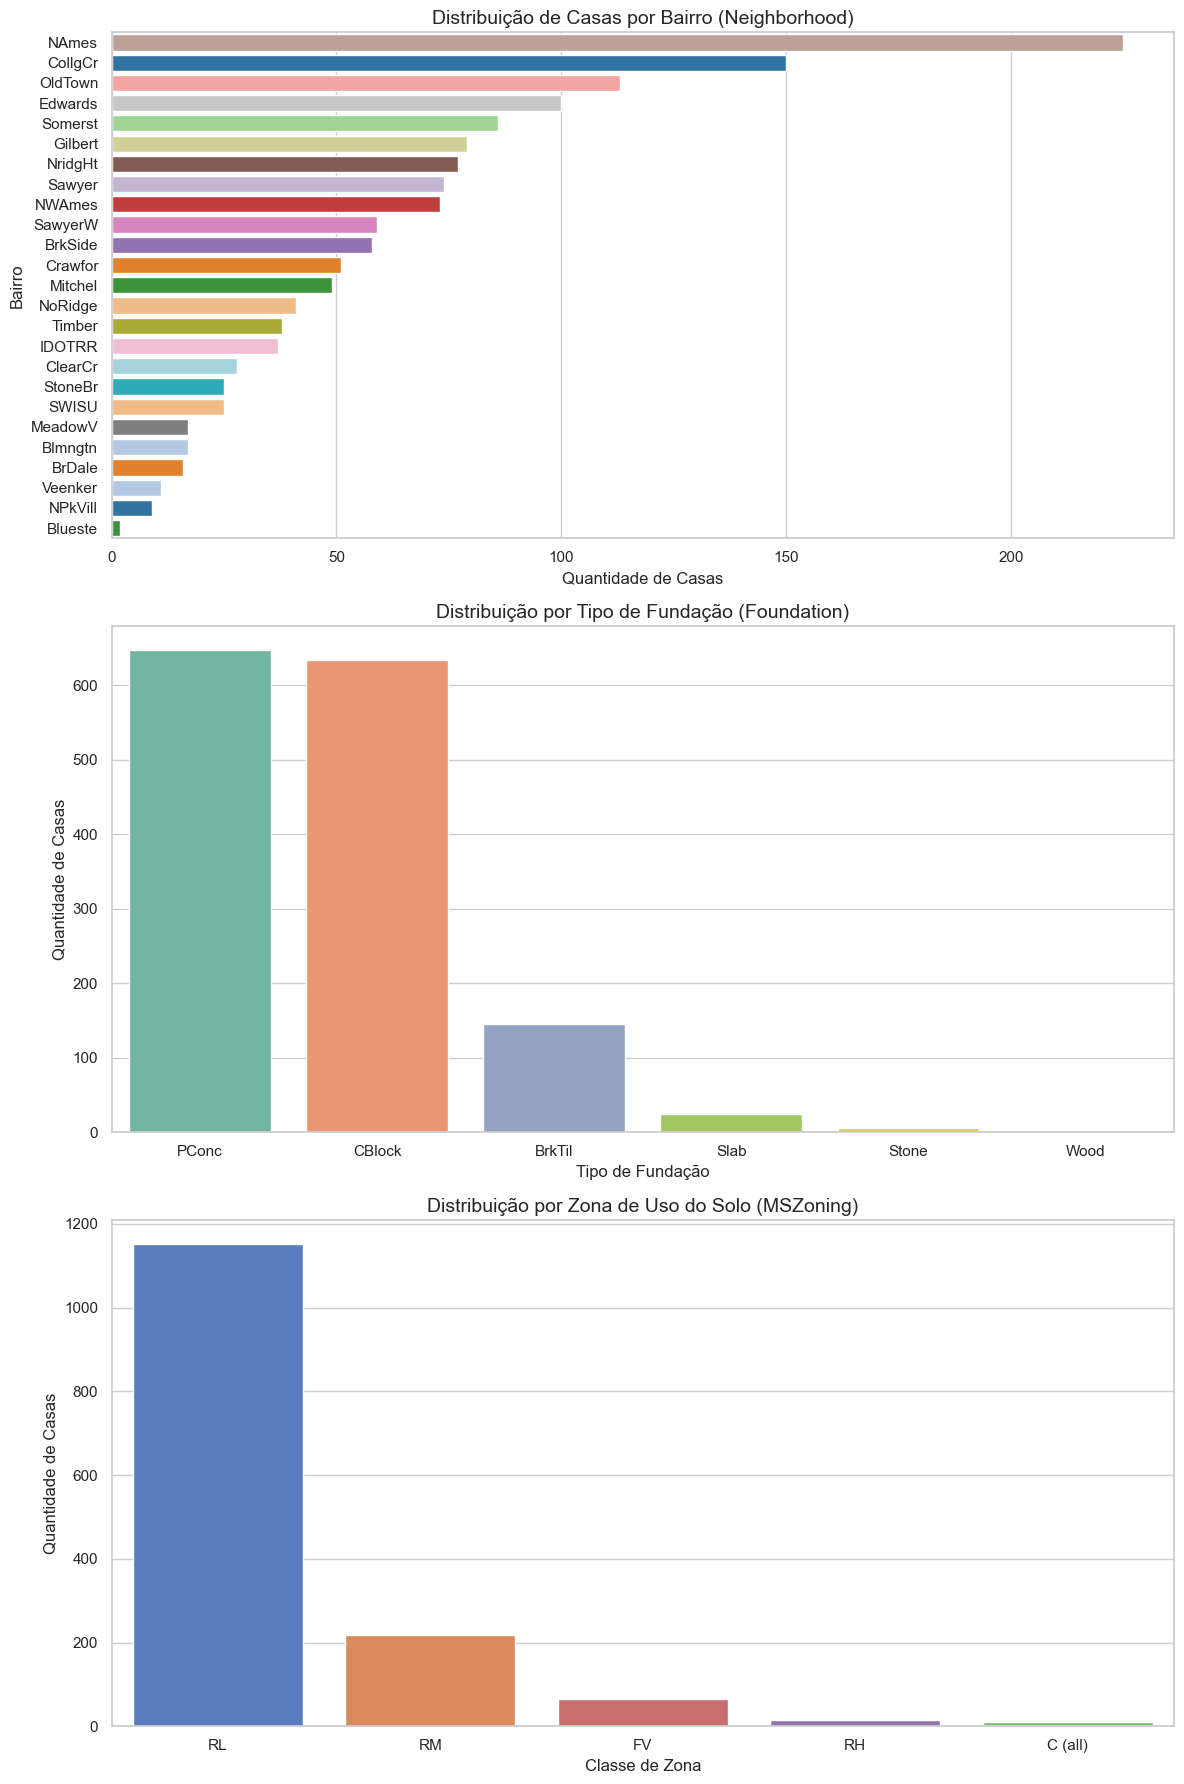

In [266]:
# Objetivo: Plotar a frequência das variáveis categóricas corrigindo paletas e avisos do Seaborn
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Neighborhood (Usando 'tab20' para cobrir a grande variedade de bairros)
sns.countplot(
    y=houses['Neighborhood'], 
    order=houses['Neighborhood'].value_counts().index, 
    ax=axes[0], 
    hue=houses['Neighborhood'], 
    legend=False, 
    palette='tab20'
)
axes[0].set_title('Distribuição de Casas por Bairro (Neighborhood)', fontsize=14)
axes[0].set_xlabel('Quantidade de Casas')
axes[0].set_ylabel('Bairro')

# 2. Foundation (Substituído o erro por 'Set2')
sns.countplot(
    x=houses['Foundation'], 
    order=houses['Foundation'].value_counts().index, 
    ax=axes[1], 
    hue=houses['Foundation'], 
    legend=False, 
    palette='Set2'
)
axes[1].set_title('Distribuição por Tipo de Fundação (Foundation)', fontsize=14)
axes[1].set_xlabel('Tipo de Fundação')
axes[1].set_ylabel('Quantidade de Casas')

# 3. MSZoning (Ajustado para 'muted')
sns.countplot(
    x=houses['MSZoning'], 
    order=houses['MSZoning'].value_counts().index, 
    ax=axes[2], 
    hue=houses['MSZoning'], 
    legend=False, 
    palette='muted'
)
axes[2].set_title('Distribuição por Zona de Uso do Solo (MSZoning)', fontsize=14)
axes[2].set_xlabel('Classe de Zona')
axes[2].set_ylabel('Quantidade de Casas')

plt.tight_layout()
plt.show()

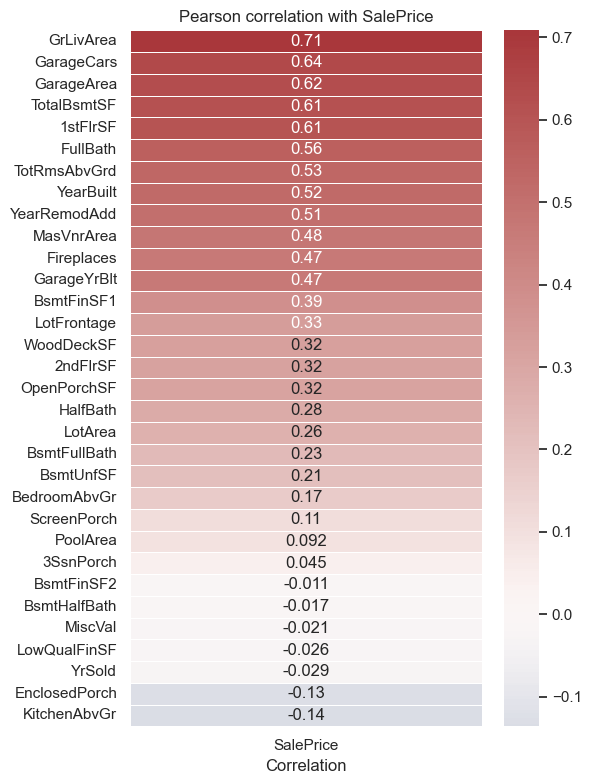

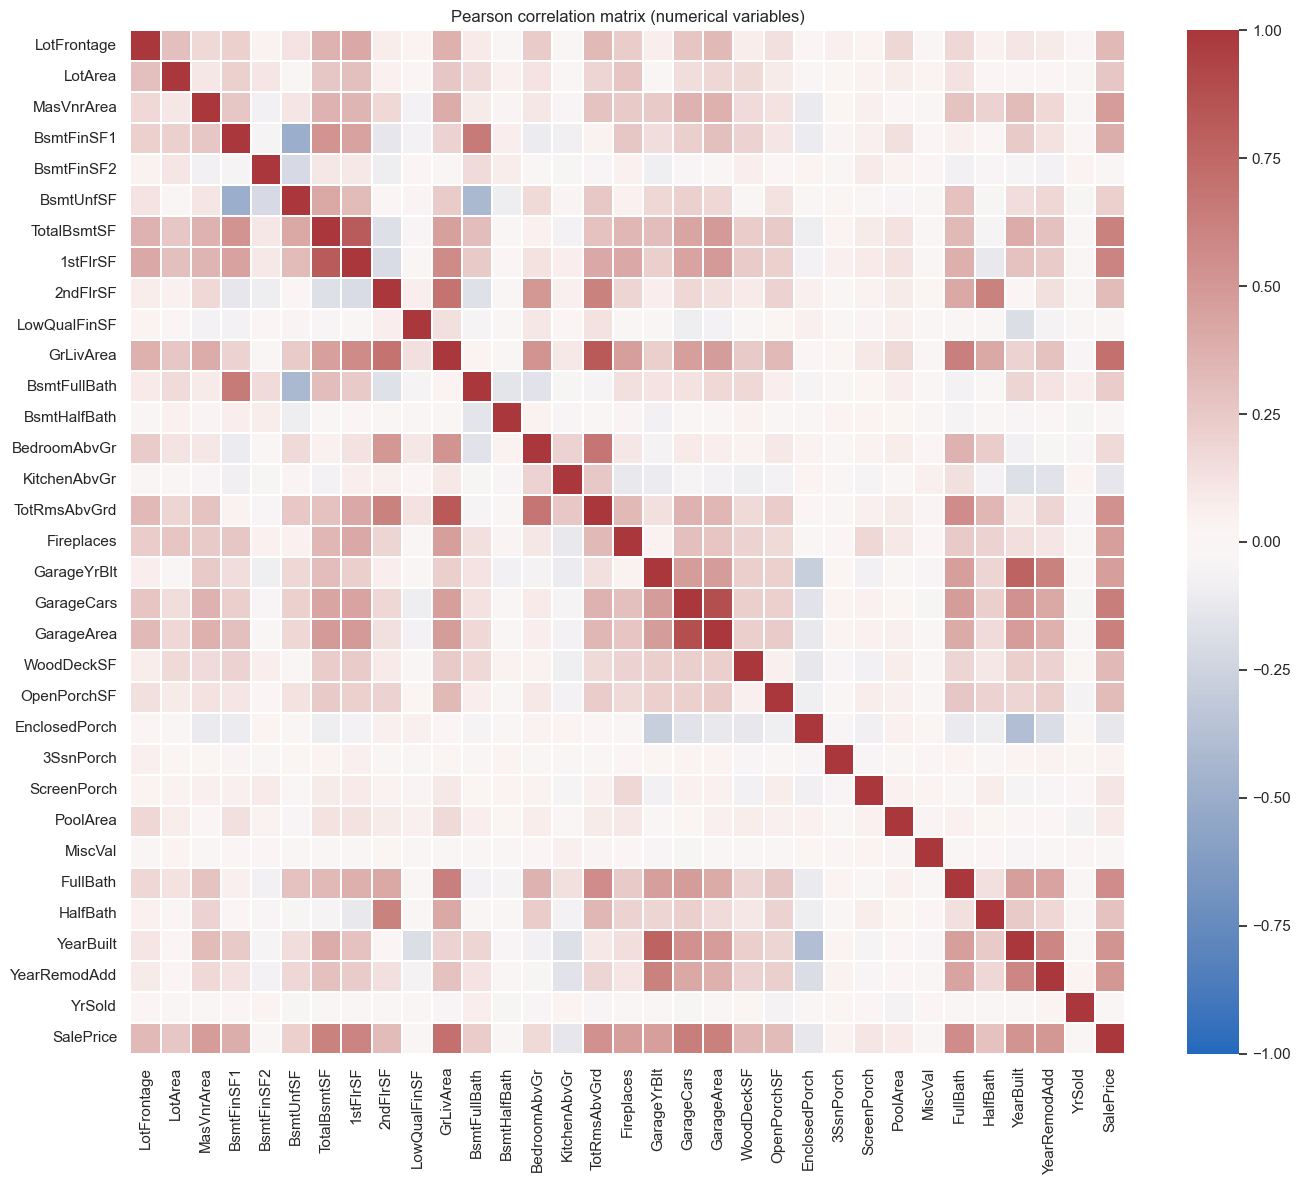

In [267]:
# Heatmaps: Pearson correlation with SalePrice and among numerical variables
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ensure numerical_cols is available in the notebook scope
cols = numerical_cols.copy()
if 'SalePrice' not in cols:
    cols = cols + ['SalePrice']

# compute Pearson correlation matrix
corr_matrix = houses[cols].corr(method='pearson')

# 1) Correlation of numerical variables with SalePrice
corr_with_target = corr_matrix['SalePrice'].drop('SalePrice')
corr_with_target = corr_with_target.sort_values(ascending=False)
plt.figure(figsize=(6, max(4, len(corr_with_target)*0.25)))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='vlag', center=0, linewidths=0.5)
plt.title('Pearson correlation with SalePrice')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# 2) Heatmap of correlation matrix among numerical variables
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='vlag', center=0, vmax=1, vmin=-1, linewidths=0.25)
plt.title('Pearson correlation matrix (numerical variables)')
plt.tight_layout()
plt.show()

Coeficiente de Spearman:

The Spearman correlation coefficient is defined as the Pearson correlation coefficient between the rank variables.
Ranking is a data transformation in which numerical or ordinal data are replaced by their rank when the data are sorted.

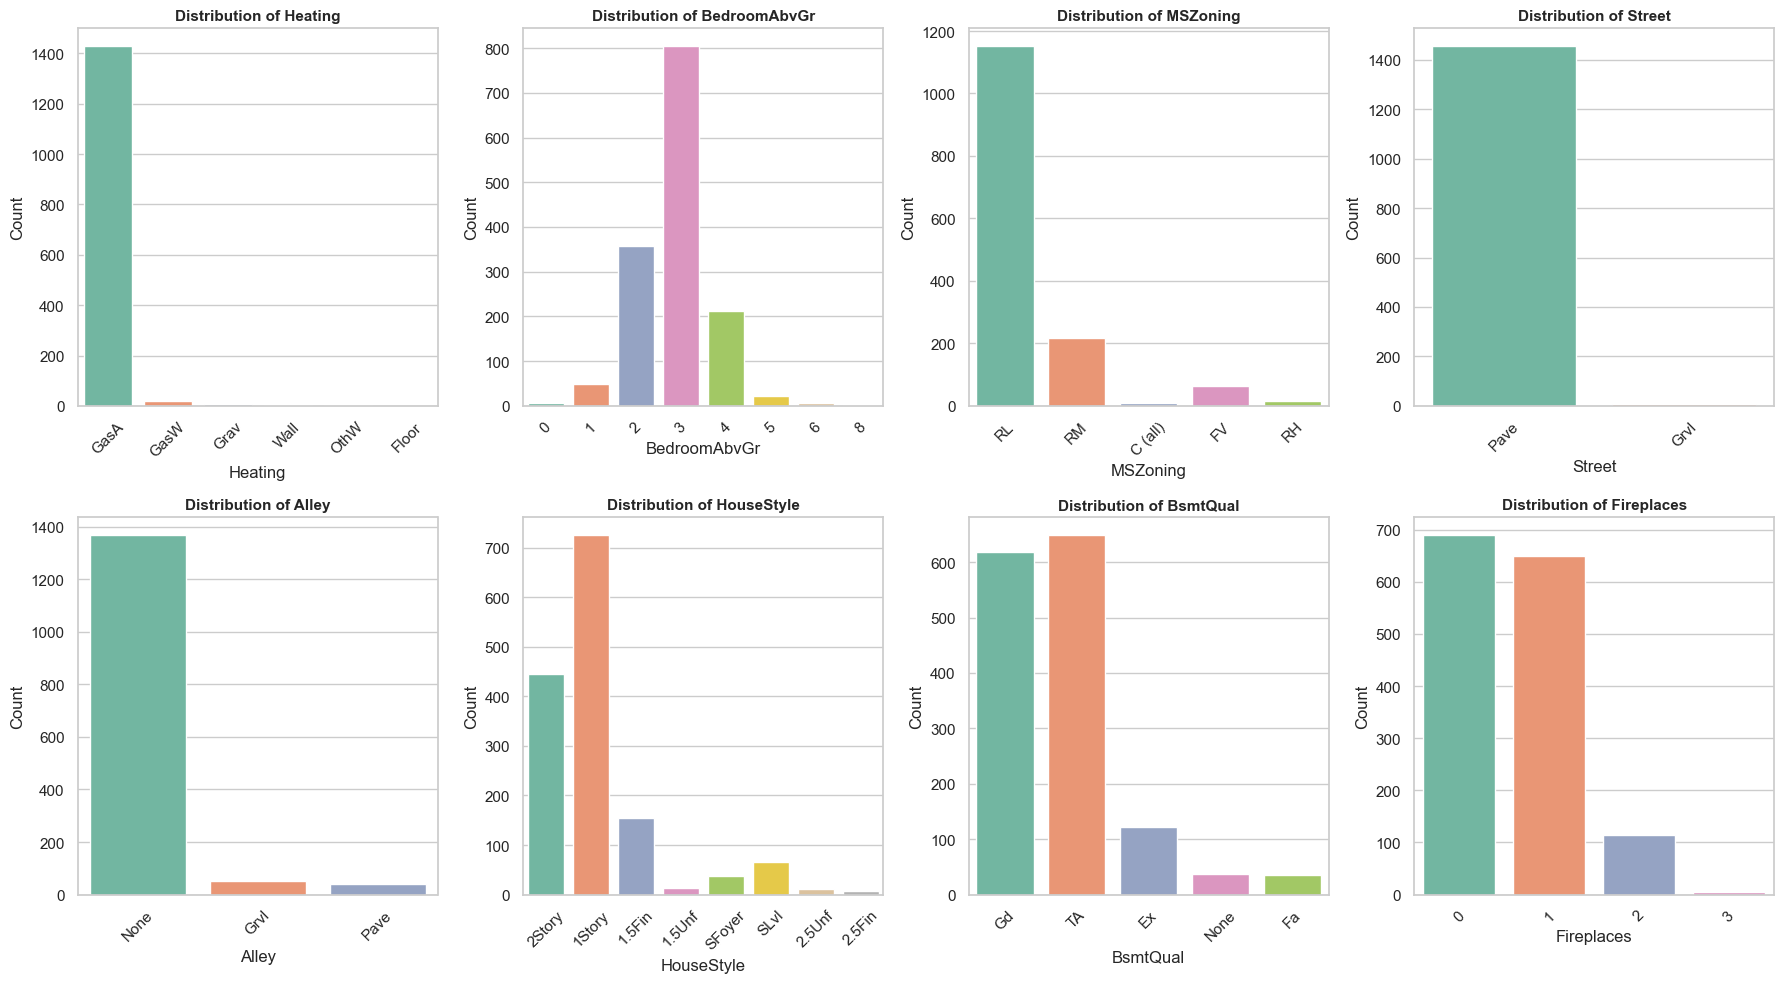

In [268]:
# Create histograms (countplots) for each categorical variable
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Heating', 'BedroomAbvGr', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtQual', 'Fireplaces']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    sns.countplot(data=houses, x=var, ax=axes[idx], palette='Set2', hue=var, legend=False)
    axes[idx].set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


`Neighborhood`: Locais físicos dentro dos limites da cidade de Ames

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker

In [269]:
# Check missing values in Neighborhood before plotting
missing_neighborhood = houses['Neighborhood'].isna().sum()
print(f'Missing values in Neighborhood: {missing_neighborhood}')

houses['Neighborhood'].value_counts(dropna=False)

Missing values in Neighborhood: 0


Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

C:\Users\pedro\AppData\Local\Temp\ipykernel_30320\651630342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')


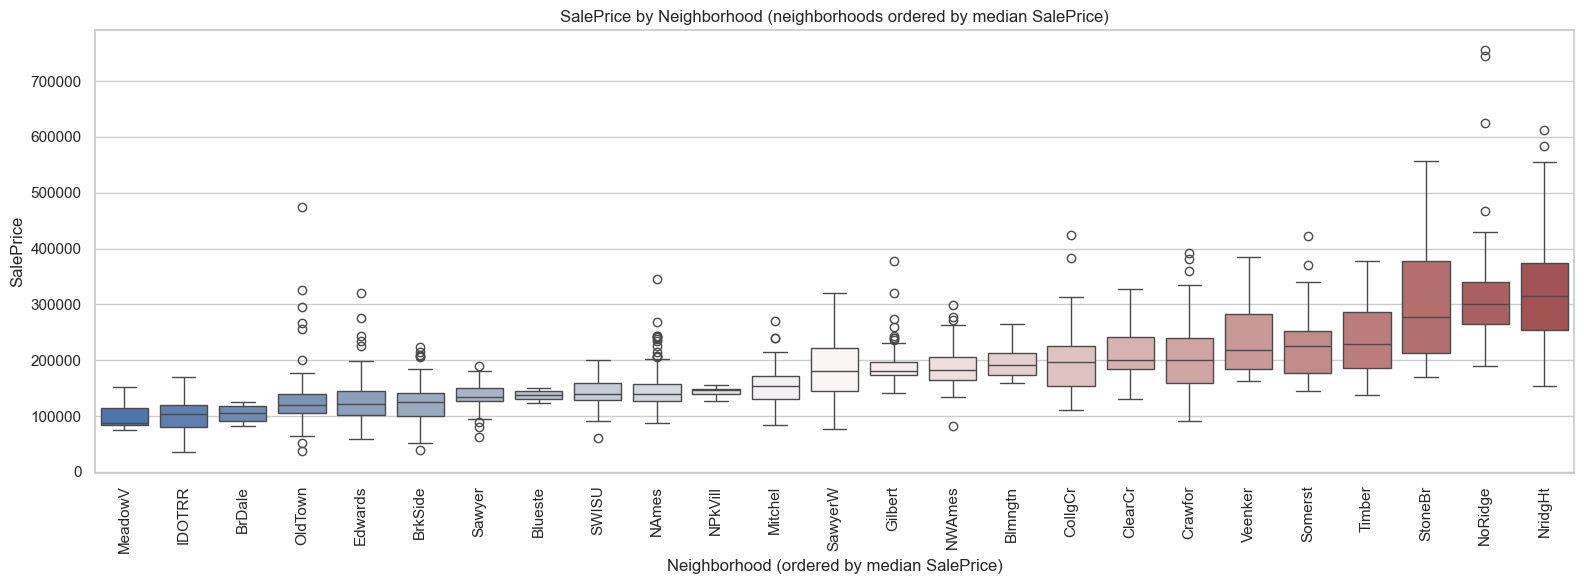

In [270]:
# Boxplot of SalePrice by Neighborhood ordered by median SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

# compute neighborhood medians and order neighborhoods from smallest to largest median
neigh_medians = houses.groupby('Neighborhood')['SalePrice'].median().sort_values()
order = neigh_medians.index

plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood (neighborhoods ordered by median SalePrice)')
plt.xlabel('Neighborhood (ordered by median SalePrice)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

O que fazer com bairros que possuem poucas instâncias??
- Agrupar num grupo "Outros"? --> usar mediana??

Bairros com menos de 30 instâncias
- ``Blueste``
- ``NPkVill``
- ``Veenker``
- ``BrDale``
- ``MeadowV``
- ``Blmngtn``
- ``StoneBr``
- ``SWISU``
- ``ClearCr``

In [271]:
# 1) Check missing values and basic stats for GrLivArea
missing_grliv = houses['GrLivArea'].isna().sum()
print(f"Missing values in GrLivArea: {missing_grliv}")

# Show summary statistics to get a sense of distribution and outliers
houses['GrLivArea'].describe()


Missing values in GrLivArea: 0


count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

Pearson correlation: 0.709
Spearman correlation: 0.731
Kendall correlation: 0.544


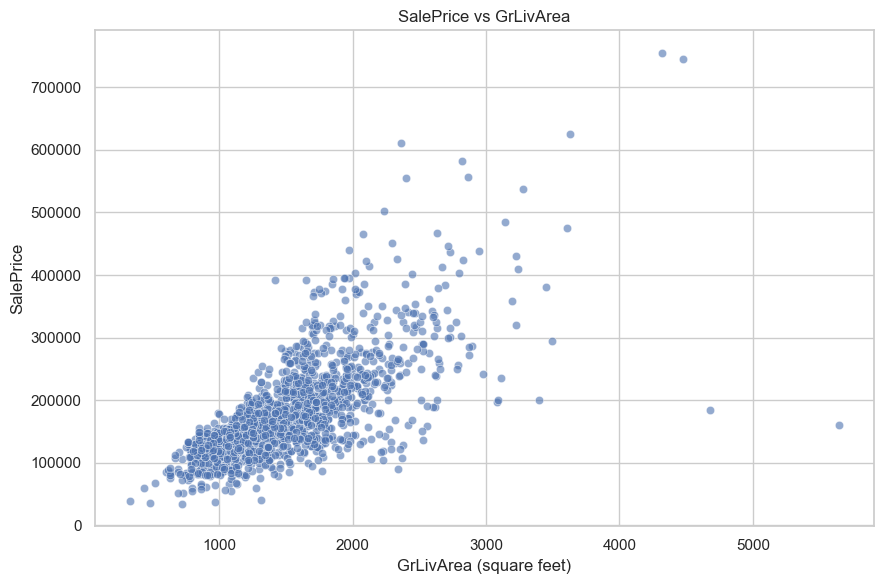

In [272]:
# Calculating correlations and plotting SalePrice vs GrLivArea
import matplotlib.pyplot as plt
import seaborn as sns

# compute Pearson, Spearman, and Kendall correlations
pearson_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='pearson')
spearman_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='spearman')
kendall_corr = houses['GrLivArea'].corr(houses['SalePrice'], method='kendall')

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Kendall correlation: {kendall_corr:.3f}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=houses, x='GrLivArea', y='SalePrice', alpha=0.6)
plt.title('SalePrice vs GrLivArea')
plt.xlabel('GrLivArea (square feet)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

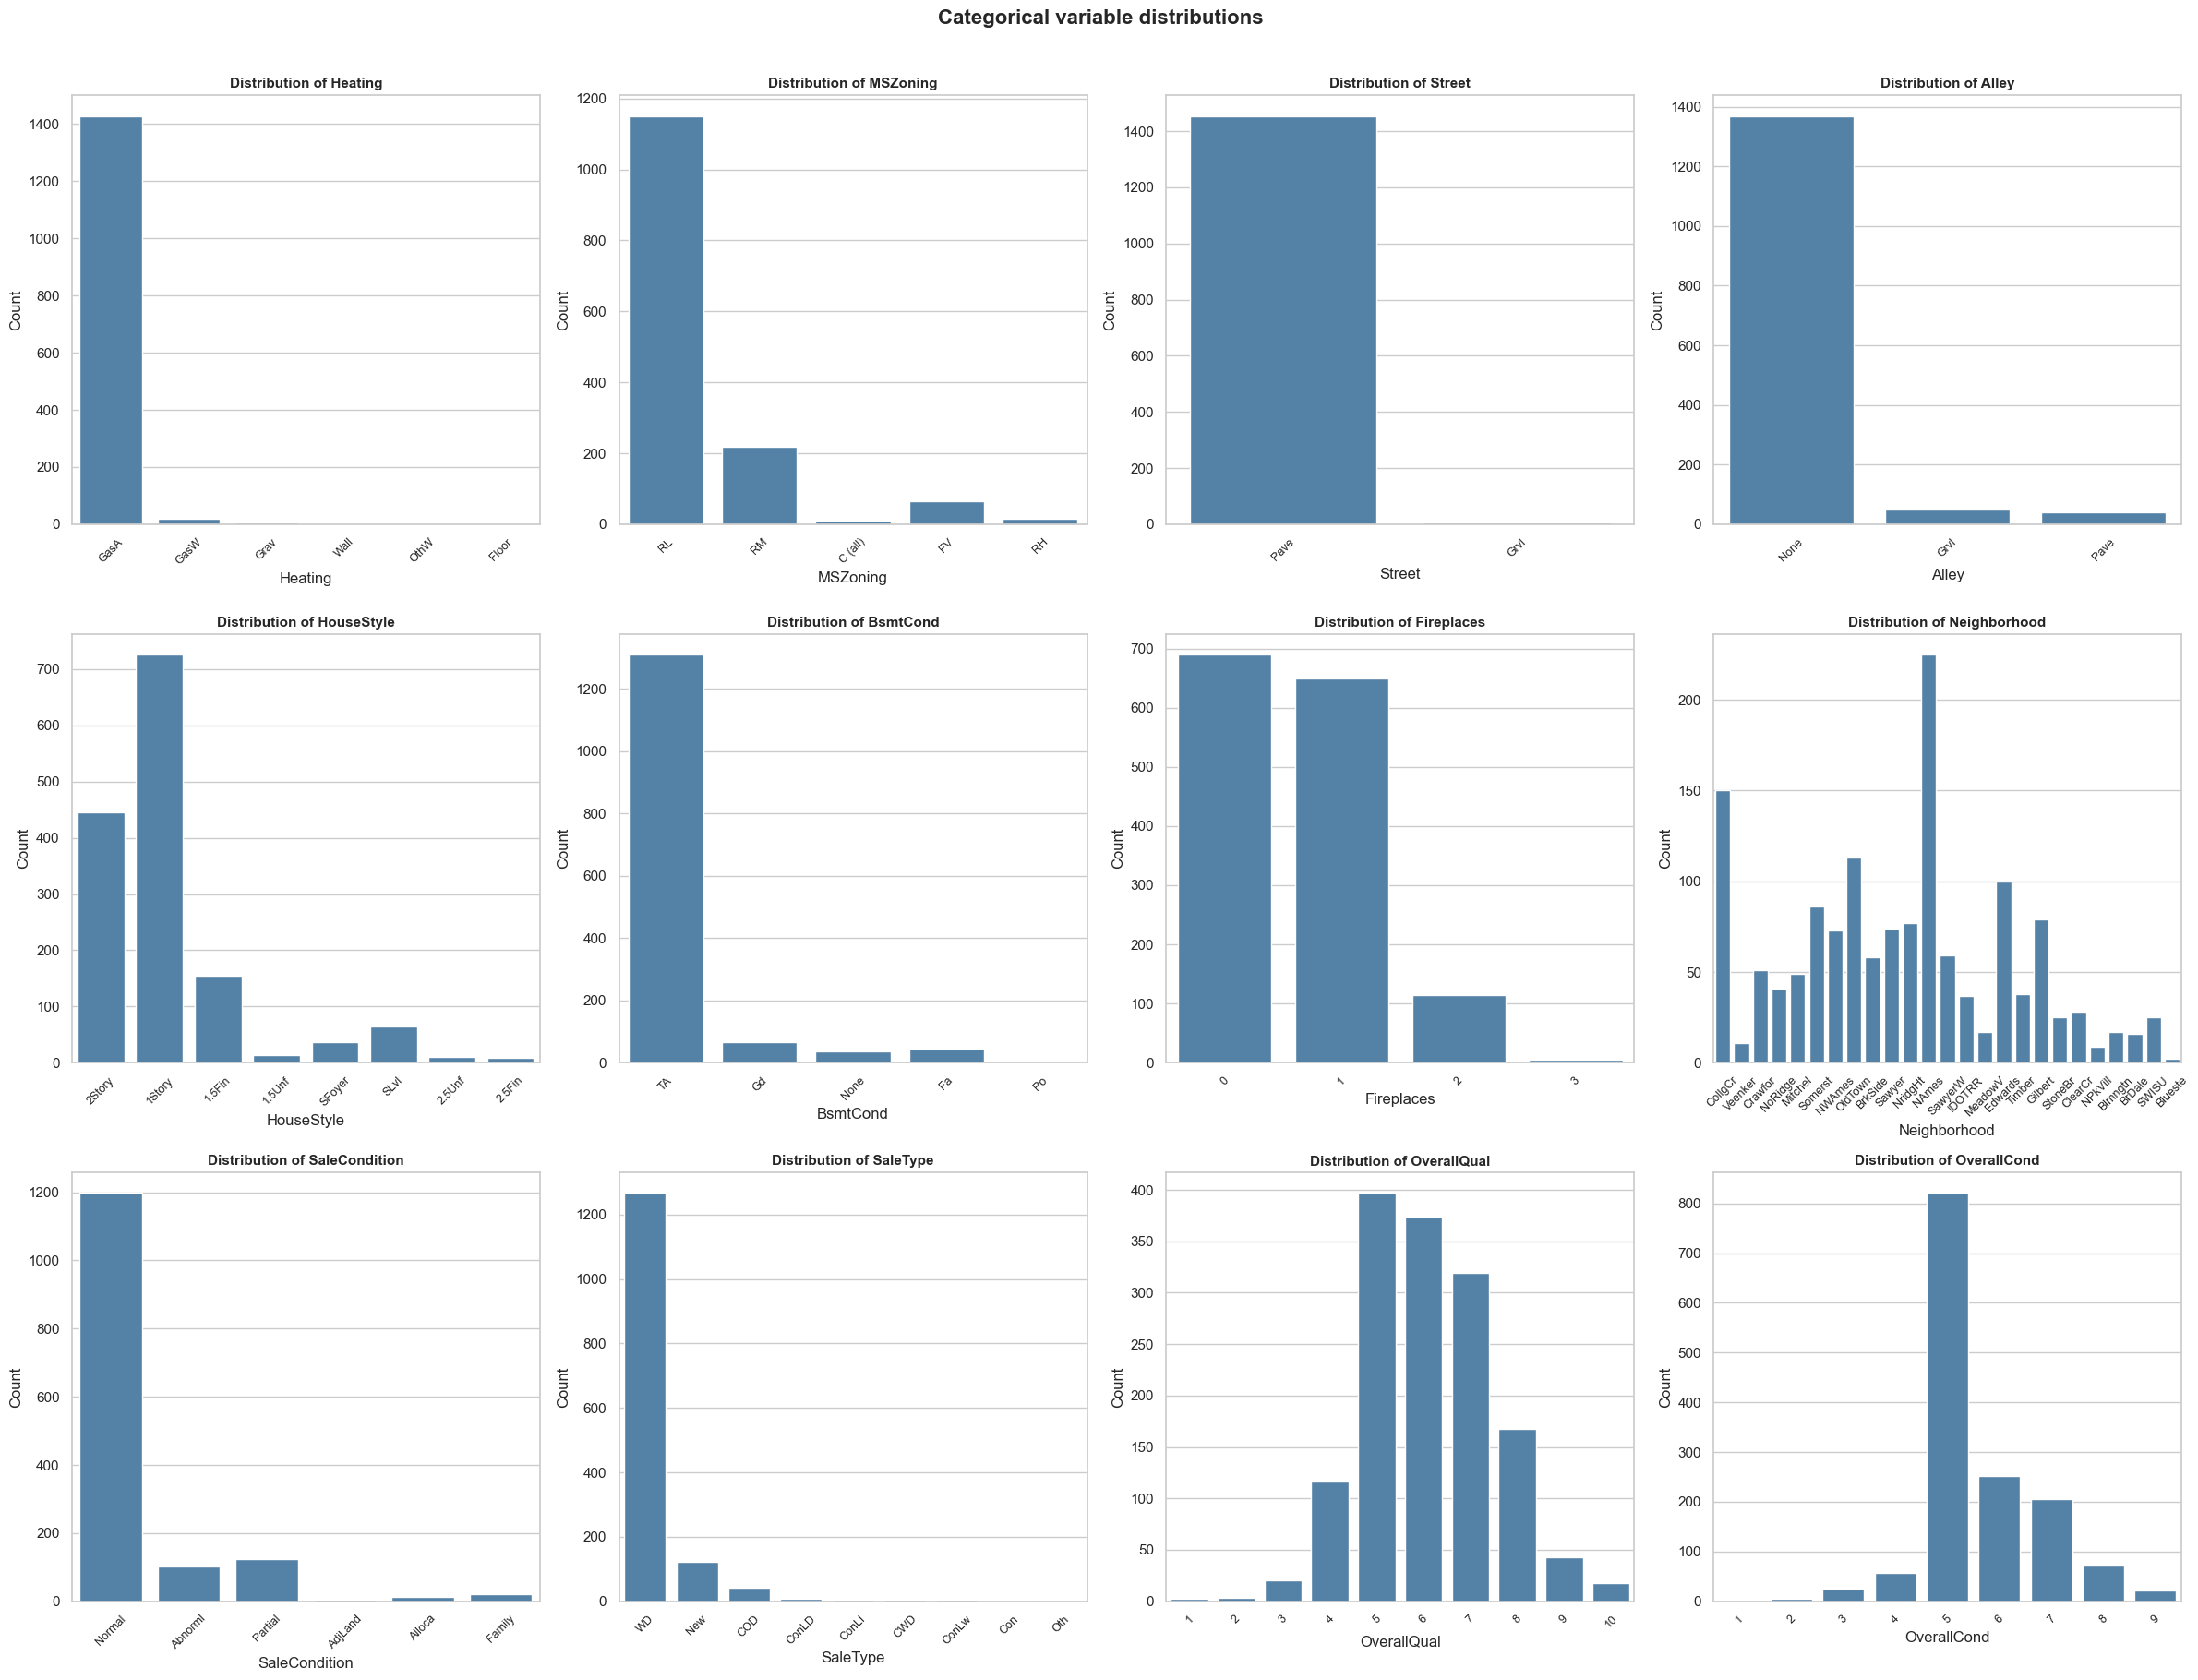

In [273]:
# Create categorical distribution plots with Count on the y axis
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Heating', 'MSZoning', 'Street', 'Alley', 'HouseStyle', 'BsmtCond', 'Fireplaces', 'Neighborhood', 'SaleCondition', 'SaleType', 'OverallQual', 'OverallCond']

fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

for idx, var in enumerate(variables):
    sns.countplot(data=houses, x=var, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)

for idx in range(len(variables), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical variable distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

histograms for BedroomAbvGr (numeric or ordinal?)